# CQT（定Q変換）+ クロマ特徴量による音楽解析

## このノートブックで学ぶこと

1. STFT と CQT の違いと、音楽解析に CQT が適している理由
2. Karplus-Strong で生成した単音・アルペジオ・和音を CQT で解析
3. クロマ特徴量（12 音名へのエネルギー分布）の計算と可視化
4. コード識別・調性判定への応用

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SR = 44100
DATA_DIR = Path('../data/cqt_chroma')
DATA_DIR.mkdir(parents=True, exist_ok=True)

NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
print('準備完了')

準備完了


---
## 1. 素材音の生成

以下の 3 パターンの音を生成する。

- **単音** — A4（440 Hz）
- **アルペジオ** — C メジャースケールを順番に弾く（各音 0.5 s）
- **和音** — Cm（C マイナーコード: C + E♭ + G を同時に鳴らす）

In [2]:
def karplus_strong(freq, duration=1.0, sr=44100, decay=0.998):
    buf = np.random.default_rng(int(freq)).uniform(-1, 1, max(2, int(round(sr/freq))))
    n = int(sr * duration)
    out = np.empty(n)
    for i in range(n):
        idx = i % len(buf)
        out[i] = buf[idx]
        nxt = (idx + 1) % len(buf)
        buf[idx] = decay * 0.5 * (buf[idx] + buf[nxt])
    return out / (np.max(np.abs(out)) + 1e-9)


def note_to_hz(note_name: str) -> float:
    """例: 'C4' → 261.63 Hz"""
    return librosa.note_to_hz(note_name)


# ---- 単音 ----
wave_single = karplus_strong(440.0, duration=3.0)

# ---- C メジャースケール アルペジオ ----
SCALE_NOTES = ['C4','D4','E4','F4','G4','A4','B4','C5']
NOTE_DUR = 0.6  # 秒
arp_parts = [karplus_strong(note_to_hz(n), NOTE_DUR) for n in SCALE_NOTES]
wave_arpeggio = np.concatenate(arp_parts)

# ---- Cm コード（C + Eb + G 同時発音）----
CHORD_CM = ['C4', 'Eb4', 'G4']
chord_parts = [karplus_strong(note_to_hz(n), 3.0) for n in CHORD_CM]
wave_chord = sum(chord_parts) / len(chord_parts)

for name, wave in [('single_A4', wave_single),
                   ('arpeggio_Cmajor', wave_arpeggio),
                   ('chord_Cm', wave_chord)]:
    sf.write(DATA_DIR / f'{name}.wav', wave, SR)

print('生成完了')
print(f'  単音 A4         : {len(wave_single)/SR:.1f} s')
print(f'  Cメジャースケール: {len(wave_arpeggio)/SR:.1f} s')
print(f'  Cm コード       : {len(wave_chord)/SR:.1f} s')

生成完了
  単音 A4         : 3.0 s
  Cメジャースケール: 4.8 s
  Cm コード       : 3.0 s


---
## 2. CQT と STFT の比較

| 項目 | STFT | CQT |
|---|---|---|
| 周波数スケール | 線形（等間隔） | 対数（倍音に沿った等間隔） |
| 音楽のオクターブ | 上がるほど密になる | 常に同じ幅 |
| 1半音 = 1ビン | 低音でほぼ不可能 | 常に成立（`bins_per_octave=12`） |
| 低音域分解能 | 粗い | 高い |
| 計算コスト | 低 | やや高い |

アルペジオ音を使って、同じ音符が CQT では等間隔に並ぶことを確認する。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:48: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:48: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:48: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:48: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:48: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_8

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12499 (\N{KATAKANA LETTER BI}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/3617013805.py:49: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykerne

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/pyt

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12499 (\N{KATAKANA LETTER BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/researc

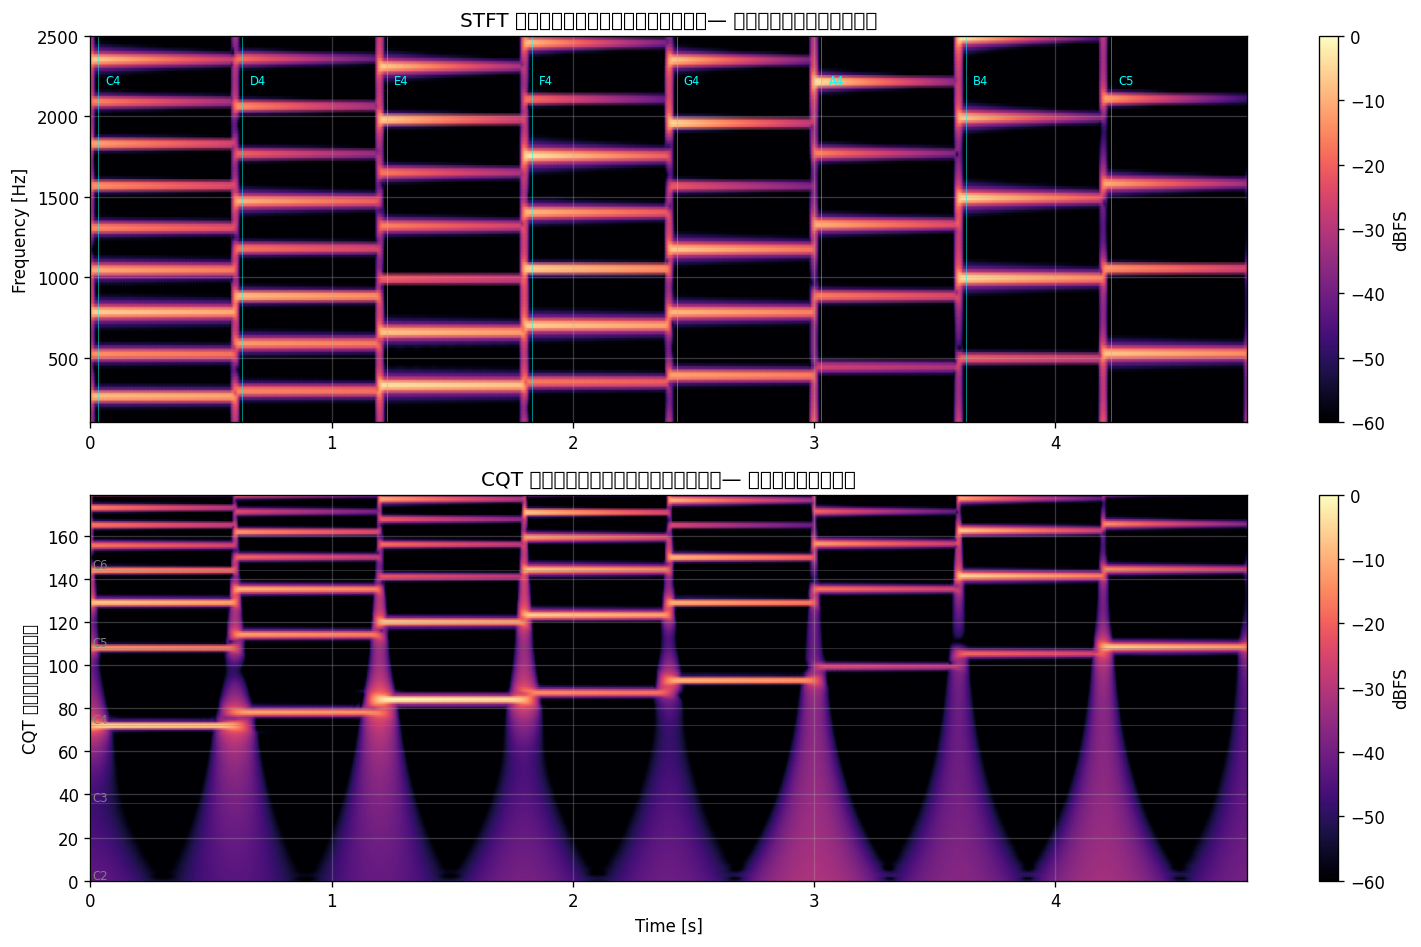

In [3]:
y = wave_arpeggio
N_FFT, HOP = 2048, 256

# STFT スペクトログラム
D_stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)
S_stft = librosa.amplitude_to_db(np.abs(D_stft), ref=np.max)

# CQT スペクトログラム（C2 〜 C7, 36ビン/オクターブ）
C = librosa.cqt(y, sr=SR, hop_length=HOP,
                fmin=librosa.note_to_hz('C2'),
                n_bins=5 * 36, bins_per_octave=36)
S_cqt = librosa.amplitude_to_db(np.abs(C), ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
t = librosa.frames_to_time(np.arange(S_stft.shape[1]), sr=SR, hop_length=HOP)

# STFT
freqs_stft = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
im0 = axes[0].pcolormesh(t, freqs_stft, S_stft,
                          shading='gouraud', cmap='magma', vmin=-60, vmax=0)
axes[0].set_ylim(100, 2500)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_title('STFT スペクトログラム（線形スケール）— 上のオクターブが密になる')
plt.colorbar(im0, ax=axes[0], label='dBFS')

# スケール音名の縦線
for i, note in enumerate(SCALE_NOTES):
    axes[0].axvline(i * NOTE_DUR + NOTE_DUR*0.05, color='cyan', linewidth=0.6, alpha=0.5)
    axes[0].text(i * NOTE_DUR + NOTE_DUR*0.1, 2200, note, fontsize=7, color='cyan')

# CQT
t_cqt = librosa.frames_to_time(np.arange(S_cqt.shape[1]), sr=SR, hop_length=HOP)
im1 = axes[1].pcolormesh(t_cqt, np.arange(S_cqt.shape[0]), S_cqt,
                          shading='gouraud', cmap='magma', vmin=-60, vmax=0)
axes[1].set_ylabel('CQT ビン（対数周波数）')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('CQT スペクトログラム（対数スケール）— 音符が等間隔に並ぶ')
plt.colorbar(im1, ax=axes[1], label='dBFS')

# オクターブ境界を横線で示す
for i, (label, note) in enumerate(zip(['C2','C3','C4','C5','C6'],
                                       ['C2','C3','C4','C5','C6'])):
    bin_pos = i * 36
    if bin_pos < S_cqt.shape[0]:
        axes[1].axhline(bin_pos, color='gray', linewidth=0.5, alpha=0.4)
        axes[1].text(0.01, bin_pos + 1, label, fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(DATA_DIR / 'cqt_vs_stft.png', bbox_inches='tight')
plt.show()

---
## 3. クロマ特徴量（Chroma Features）

クロマ特徴量は、全周波数成分を **12 の音名（C, C#, D...B）** に折り畳んだもの。  
オクターブを問わず「どの音名が鳴っているか」を示す。調性・和音解析の基礎。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:22: UserWarning: Glyph 21336 (\N{CJK UNIFIED IDEOGRAPH-5358}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:22: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:22: UserWarning: Glyph 12384 (\N{HIRAGANA LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:22: UserWarning: Glyph 12369 (\N{HIRAGANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:22: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:23: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'chroma_comparison.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:23: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'chroma_comparison.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'chroma_comparison.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/607845079.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'chroma_comparison.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrs

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21336 (\N{CJK UNIFIED IDEOGRAPH-5358}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12384 (\N{HIRAGANA LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12369 (\N{HIRAGANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/resear

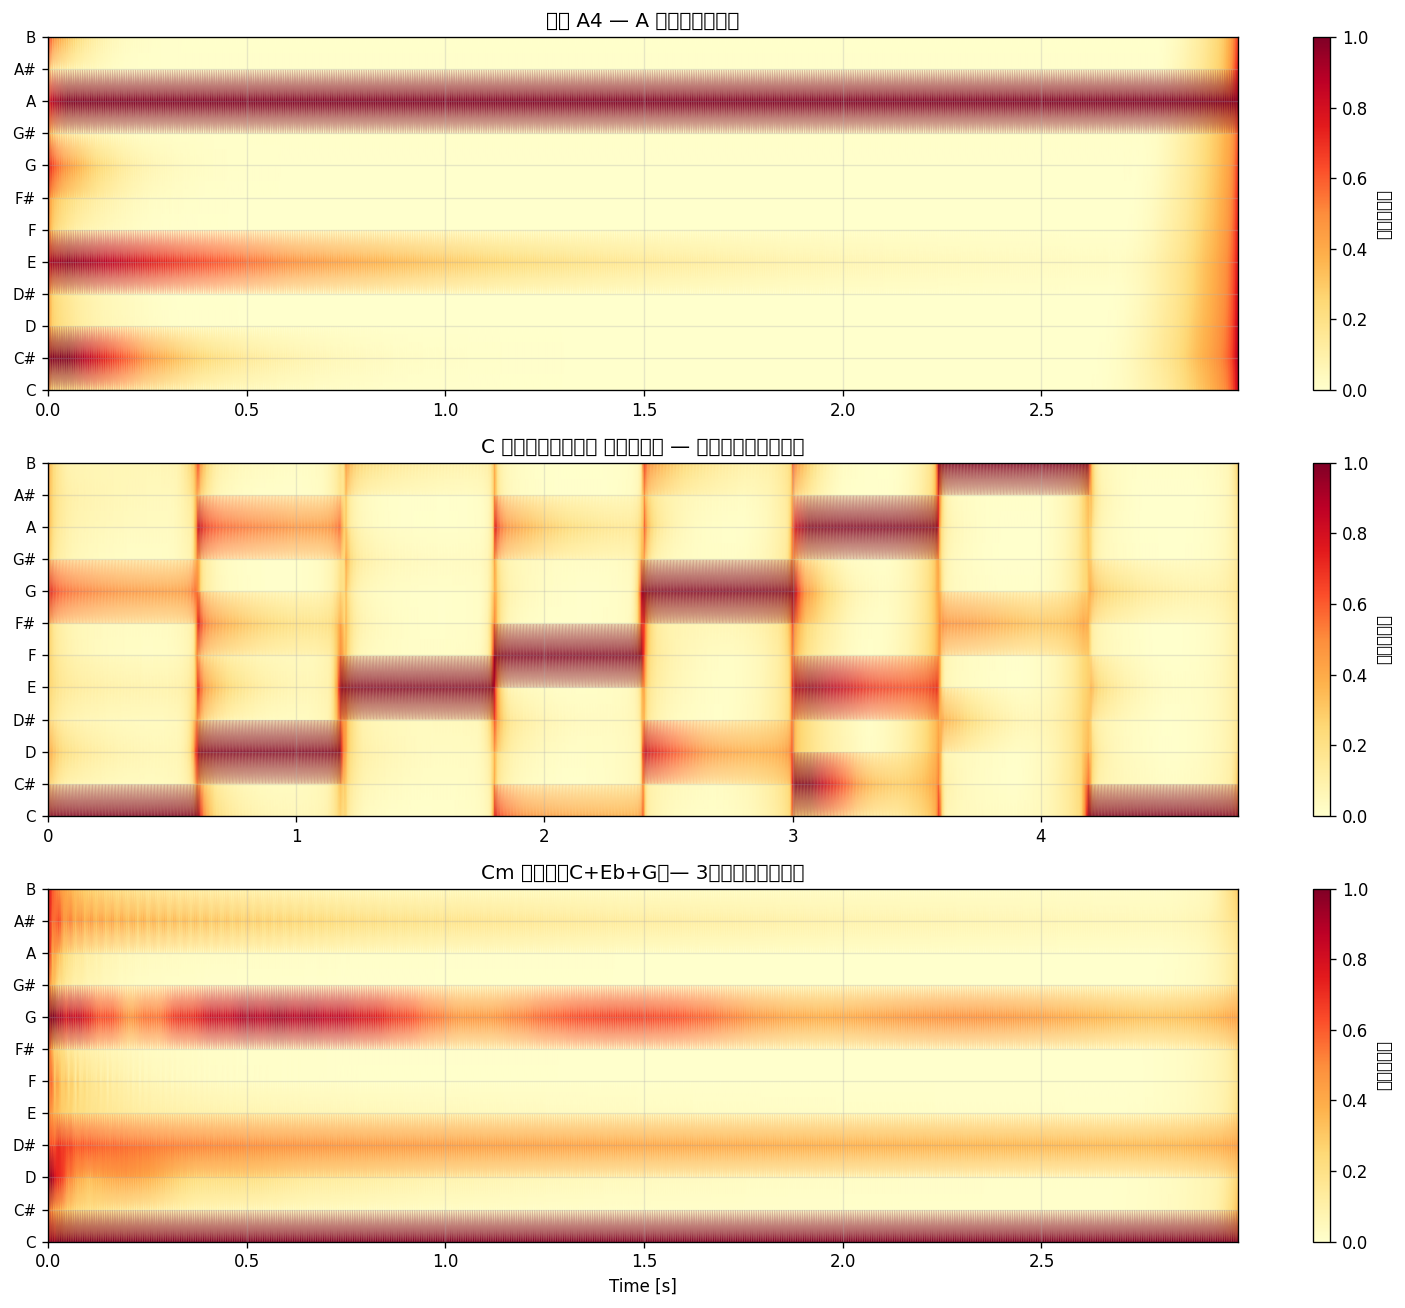

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

SIGNALS = [
    (wave_single,   'chroma_single',   f'単音 A4 — A だけが光るはず'),
    (wave_arpeggio, 'chroma_arpeggio', 'C メジャースケール アルペジオ — 各音名が順番に点灯'),
    (wave_chord,    'chroma_chord',    'Cm コード（C+Eb+G）— 3音名が同時に点灯'),
]

for ax, (wave, fname, title) in zip(axes, SIGNALS):
    chroma = librosa.feature.chroma_cqt(y=wave, sr=SR, hop_length=HOP,
                                         fmin=librosa.note_to_hz('C2'),
                                         bins_per_octave=36)
    t_c = librosa.frames_to_time(np.arange(chroma.shape[1]), sr=SR, hop_length=HOP)
    im = ax.pcolormesh(t_c, np.arange(12), chroma,
                       shading='gouraud', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(NOTE_NAMES, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='エネルギー')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.savefig(DATA_DIR / 'chroma_comparison.png', bbox_inches='tight')
plt.show()

---
## 4. クロマから和音・調性を読み取る

クロマの時間平均ベクトルを見ると、「この音楽でどの音名が多く使われているか」が分かる。  
さらに主要和音（メジャー・マイナー）のテンプレートと照合すれば、コード検出ができる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/1128304968.py:50: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/1128304968.py:50: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/1128304968.py:50: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/1128304968.py:50: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89063/1128304968.py:50: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7

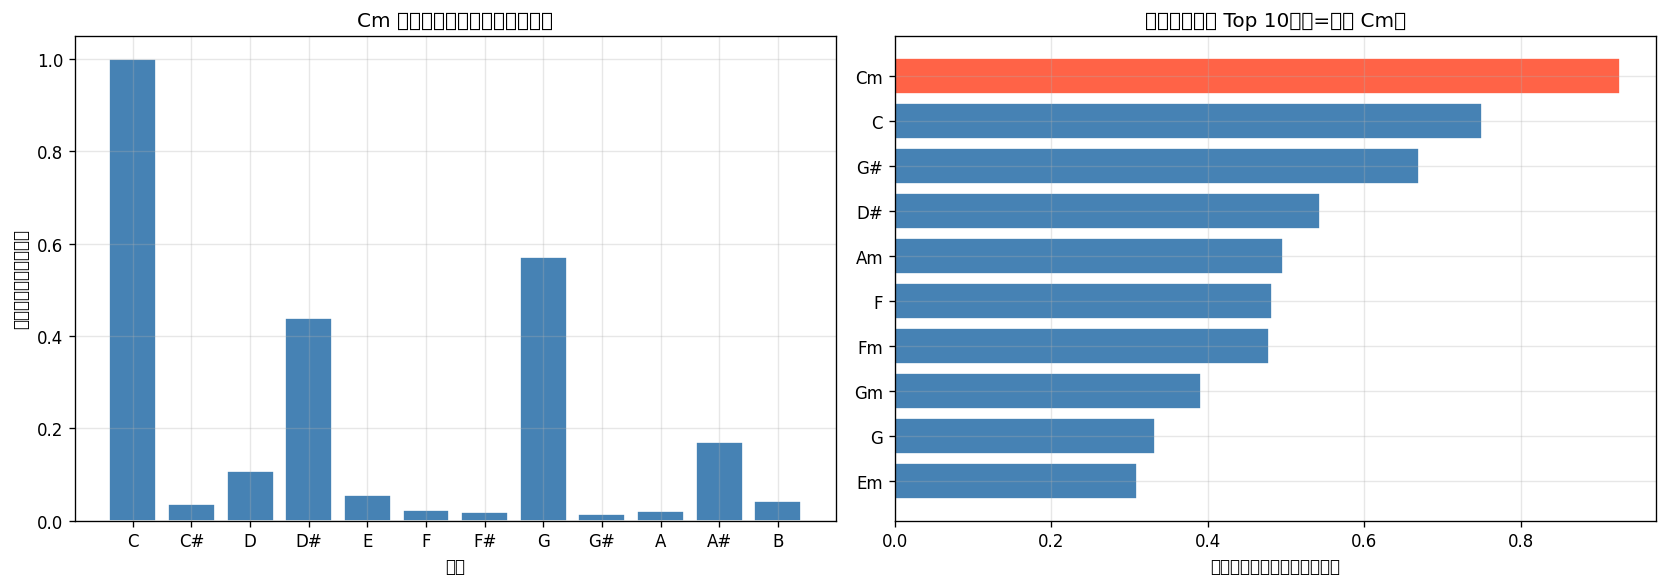

上位3コード: Cm (0.927), C (0.750), G# (0.670)


In [5]:
# コードテンプレート（1 = その音名が含まれる）
def chord_template(root: int, chord_type: str) -> np.ndarray:
    """root: 音名インデックス (C=0), chord_type: 'major'/'minor'"""
    t = np.zeros(12)
    if chord_type == 'major':
        intervals = [0, 4, 7]
    else:  # minor
        intervals = [0, 3, 7]
    for iv in intervals:
        t[(root + iv) % 12] = 1.0
    return t / np.linalg.norm(t)


# Cm コードのクロマ平均と全コードテンプレートの類似度
chroma_cm = librosa.feature.chroma_cqt(
    y=wave_chord, sr=SR, hop_length=HOP,
    fmin=librosa.note_to_hz('C2'), bins_per_octave=36
)
chroma_mean = chroma_cm.mean(axis=1)
chroma_norm = chroma_mean / (np.linalg.norm(chroma_mean) + 1e-9)

scores = []
for root in range(12):
    for ctype in ['major', 'minor']:
        tmpl = chord_template(root, ctype)
        score = float(np.dot(chroma_norm, tmpl))
        scores.append({'note': NOTE_NAMES[root], 'type': ctype,
                        'label': f"{NOTE_NAMES[root]}{'m' if ctype=='minor' else ''}",
                        'score': score})

scores.sort(key=lambda x: x['score'], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# クロマ平均ベクトル
axes[0].bar(NOTE_NAMES, chroma_mean, color='steelblue', edgecolor='white')
axes[0].set_xlabel('音名')
axes[0].set_ylabel('平均クロマエネルギー')
axes[0].set_title('Cm コードのクロマ平均ベクトル')

# コード類似度 Top 10
top10 = scores[:10]
labels = [s['label'] for s in top10]
vals   = [s['score'] for s in top10]
bar_colors = ['tomato' if s['label'] == 'Cm' else 'steelblue' for s in top10]
axes[1].barh(labels[::-1], vals[::-1], color=bar_colors[::-1], edgecolor='white')
axes[1].set_xlabel('テンプレートとの内積スコア')
axes[1].set_title('コード類似度 Top 10（赤=正解 Cm）')

plt.tight_layout()
plt.savefig(DATA_DIR / 'chord_detection.png', bbox_inches='tight')
plt.show()

print(f'上位3コード: ' + ', '.join(f"{s['label']} ({s['score']:.3f})" for s in scores[:3]))

---
## まとめ

| 確認できたこと | 詳細 |
|---|---|
| CQT の利点 | 対数周波数スケールにより、どのオクターブでも音符が等間隔に現れる |
| クロマの直感性 | どの音名が鳴っているかを一目で確認できる |
| コード検出 | クロマ平均とテンプレートの内積で簡易コード検出ができる |

### 次に試すこと

- `bins_per_octave=12` にして半音単位の分解能を確認する
- Tonnetz 特徴量を計算して和声空間を可視化する
- コード進行の変化をフレームごとに追跡する（コードシーケンス解析）
- 実際の楽曲音源のクロマを解析して調性を判定する